# 검증 기반 변수선택을 이용한 소매 수요 모델링: 가격 및 판촉 요인

## 요약

소매 애널리틱스 팀이 가격, 판촉 수단, 마케팅 지출, 제품 카테고리별 계절성의 함수로 주간 SKU 단위 판매수량을 모델링한다. `PROC GLMSELECT`는 학습/검증/테스트 분할에 대해 단계적 변수선택을 적용한 선형회귀를 적합시켜, 검증 기반 선택이 수요 모델이 가격·판촉 계획에 반영되기 전에 과적합을 방지하도록 한다. 이어서 `PROC REG`가 해석 가능한 추정값, 다중공선성 진단, 관측치별 예측값을 보고하기 위해 초점을 맞춘 모델을 다시 적합시킨다.

## 데이터 출처

| 데이터셋 | 행 수 | 단위 | 주요 변수 | 설명 |
|---------|------|-------|---------------|-------------|
| `weekly_sales` | 100 | 매장-주-SKU | `units`(반응변수), `price`, `base_price`, `discount_pct`, `promo`(display/feature/none), `email_spend`, `social_spend`, `comp_price`, `holiday`, `week_of_year`, `category`(Grocery/Beverage/Snack/HouseHold), `role`(TRAIN/VAL/TEST) | 합성 판매시점(POS) 패널: SKU별 주간 판매수량이 자체 가격탄력성, 판촉 상승효과, 마케팅 지출, 경쟁사 가격, 공휴일/계절 효과에 의해 결정되며, `call streaminit` + `rand()`로 인라인 생성됨. |

# 검증 기반 변수선택을 이용한 소매 수요 모델링

소비재 소매업체의 카테고리 매니저는 SKU 수준의 **주간 판매수량**을 실제로 움직이는 요인이 무엇인지 파악하고자 한다: 자체 가격, 일시적 가격인하의 폭, 매장 내 판촉 유형, 디지털 마케팅 지출, 경쟁사 가격, 계절/공휴일 효과.

카테고리 간 상호작용을 포함한 수십 개의 후보 효과가 있으므로 과적합 위험이 크다. `PROC GLMSELECT`는 바로 이를 위해 만들어졌다 — 최소제곱을 적합시키고, 별도로 확보한 **검증** 분할을 사용해 원칙에 입각한 **변수선택**을 수행함으로써 선택된 모델이 일반화되도록 한다. (`GLMSELECT`는 SAS 고성능 회귀가 기반으로 삼는 선택 엔진이며, 아래 작업흐름은 SAS 분석가가 Base SAS/STAT에서 실제로 실행하는 것과 정확히 같다.) 이 노트북은 현실적인 합성 판매시점 패널을 생성한 다음, SAS 분석가가 실무에서 하듯 수요 모델을 적합시킨다.

## 1단계 — 합성 판매시점 패널 생성

네 가지 제품 카테고리에 걸친 매장-주-SKU 관측치 패널을 시뮬레이션한다. 판매수량은 그럴듯한 수요 구조를 따른다.

- **자체 가격**은 수요를 억제하며(음의 탄력성), 기준가 대비 할인율이 가장 큰 일시적 변동을 일으킨다.
- **판촉 유형**(display, feature, none)은 승법적 상승효과를 더한다.
- **이메일·소셜 마케팅 지출**은 체감 수익이 있지만 완만한 상승을 더한다.
- **경쟁사 가격**이 높을수록 우리 수요가 올라간다.
- **공휴일 주간**과 완만한 **계절성** 항이 기저선을 이동시킨다.

각 행을 TRAIN / VAL / TEST 역할로 배정하여 선택을 검증할 수 있게 한다. 시드값 덕분에 데이터는 재현 가능하다.

In [1]:
데이터 weekly_sales;
    호출 streaminit(20260531);
    길이 category $9 promo $7 role $5;
    배열 catbase{4} _temporary_ (180 240 150 120);
    반복 i = 1 까지 100;
        /* 제품 카테고리 */
        c = rand('table', 0.30, 0.25, 0.25, 0.20);
        만약      c = 1 이면 category = 'Grocery';
        아니면 만약 c = 2 이면 category = 'Beverage';
        아니면 만약 c = 3 이면 category = 'Snack';
        아니면               category = 'HouseHold';

        /* 가격: 기준가와 일시적 가격인하.
           품목의 45%는 0~40% 할인을 적용받고, 나머지는 0. */
        base_price   = round(2 + rand('uniform') * 8, 0.01);
        discount_pct = ifn(rand('uniform') < 0.45,
                           round(rand('uniform') * 0.40, 0.01),
                           0);
        price = round(base_price * (1 - discount_pct), 0.01);

        /* 경쟁사 가격은 우리 기준가 근처 */
        comp_price = round(base_price * (0.85 + rand('uniform') * 0.30), 0.01);

        /* 매장 내 판촉 유형 */
        p = rand('table', 0.55, 0.25, 0.20);
        만약      p = 1 이면 promo = 'None';
        아니면 만약 p = 2 이면 promo = 'Display';
        아니면               promo = 'Feature';

        /* 디지털 마케팅 지출(단위: 00달러), 우측 치우침 */
        email_spend  = round(rand('exponential') * 3, 0.1);
        social_spend = round(rand('exponential') * 2, 0.1);

        /* 계절성 */
        week_of_year = 1 + int(rand('uniform') * 52);
        season = 12 * sin(2 * constant('pi') * week_of_year / 52);
        holiday = (week_of_year IN (47 48 51 52));

        /* 수요 모델(데이터 생성 과정) */
        promo_lift = (promo = 'Display') * 35
                   + (promo = 'Feature') * 60;
        MU = catbase{c}
           + 220 * discount_pct
           - 9   * price
           + 6   * comp_price
           + promo_lift
           + 8   * LOG(1 + email_spend)
           + 5   * LOG(1 + social_spend)
           + 18  * holiday
           + season
           + 25  * discount_pct * (promo = 'Feature');

        units = round(MU + rand('normal') * 18);
        만약 units < 0 이면 units = 0;

        /* 학습 / 검증 / 테스트 분할 */
        u = rand('uniform');
        만약      u < 0.60 이면 role = 'TRAIN';
        아니면 만약 u < 0.80 이면 role = 'VAL';
        아니면                  role = 'TEST';

        출력;
    종료;
    제거 i c p u MU promo_lift season;
실행;


NOTE: DATA weekly_sales


NOTE: Wrote weekly_sales (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2단계 — 시뮬레이션 데이터 살펴보기

첫 관측치와 카테고리별 평균을 간단히 살펴보면 데이터가 소매 패널다운 형태임을 확인할 수 있다. 할인은 판촉 이벤트 주변에 몰려 있고, 평균 판매수량은 카테고리와 판촉 유형에 따라 다르다.

In [2]:
처리 인쇄 데이터=weekly_sales(obs=8) noobs 라벨;
    변수 category price base_price discount_pct promo email_spend
        comp_price holiday week_of_year units role;
    라벨 category     = "카테고리"
          price         = "판매가격"
          base_price    = "기준가격"
          discount_pct  = "할인율"
          promo         = "판촉유형"
          email_spend   = "이메일 지출"
          comp_price    = "경쟁사가격"
          holiday       = "공휴일여부"
          week_of_year  = "연중주차"
          units         = "판매수량"
          role          = "분할역할";
실행;

처리 평균 데이터=weekly_sales n mean std MIN MAX maxdec=2;
    분류 category promo;
    변수 units price discount_pct email_spend social_spend;
    라벨 category     = "카테고리"
          promo         = "판촉유형"
          units         = "판매수량"
          price         = "판매가격"
          discount_pct  = "할인율"
          email_spend   = "이메일 지출"
          social_spend  = "소셜 지출";
실행;


        카테고리          판매가격          기준가격        할인율          판촉유형            이메일 지출            경쟁사가격            공휴일여부          연중주차          판매수량          분할역할
------------  ------------  ------------  ---------  ------------  ----------------  ---------------  ---------------  ------------  ------------  ------------
HouseHold             9.18          9.18          0  None                       2.1             8.39                1            51           111  TRAIN
HouseHold             8.92          8.92          0  None                       1.9             9.35                0            33           122  TRAIN
Snack                 6.94          7.63       0.09  None                       1.4             8.34                0            11           194  TRAIN
Beverage              3.81          5.61       0.32  None                       1.3             5.01                0            43           311  TEST
HouseHold             8.35          8.35          0  None           


NOTE: PROC PRINT data=weekly_sales

NOTE: PROC PRINT completed: 8 observations printed, 11 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3단계 — 검증 분할을 이용한 단계적 선택으로 수요 모델 적합

이것이 핵심 변수선택 호출이다.

- **`PARTITION ROLEVAR=`**는 우리가 만든 `role` 변수를 이용해 어느 행이 학습·검증·테스트인지 `GLMSELECT`에 알려준다.
- **`CLASS`**는 범주형 효과를 선언한다. `category`는 빈도순으로 정렬되고, `promo`는 원래 순서를 유지한다.
- **`MODEL`**은 `|` 바 연산자와 `@2`를 사용하여 가격, 할인, 판촉, 마케팅, 경쟁사가격, 공휴일, 카테고리 사이의 주효과와 모든 이차 상호작용을 전개한다. `/ STB`는 표준화 계수를 요청하여 효과 크기를 공통 척도로 비교할 수 있게 한다.
- **`SELECTION METHOD=STEPWISE`**는 유의수준(`SLE`/`SLS`)에 따라 효과를 추가·제거하지만, **최종 모델은 검증 오차로 선택**한다(`CHOOSE=VALIDATE`) — 과적합에 대한 안전장치다. `HIERARCHY=SINGLE`은 상위 주효과가 있을 때만 상호작용을 유지하며, `DETAILS=STEPS`는 선택 경로를 출력한다.

In [3]:
처리 glmselect 데이터=weekly_sales;
    partition roleVar=role(train='TRAIN' validate='VAL' TEST='TEST');
    분류 category(order=freq) promo;
    모형 units = price | discount_pct | comp_price | promo | category
                | email_spend | social_spend | holiday @2 / stb;
    selection METHOD=stepwise(select=sl sle=0.05 sls=0.05 choose=validate)
              hierarchy=single details=steps;
    performance nthreads=4;
    라벨 units        = "판매수량"
          price         = "판매가격"
          discount_pct  = "할인율"
          comp_price    = "경쟁사가격"
          email_spend   = "이메일 지출"
          social_spend  = "소셜 지출"
          holiday       = "공휴일여부";
실행;

The GLMSELECT Procedure


Dependent Variable: UNITS 판매수량


Number of Observations Used: 60

              Class Level Information               

   Class    Levels                            Values
--------  --------  --------------------------------
category         4  Beverage Grocery HouseHold Snack
   promo         3              Display Feature None

                                                               Stepwise Selection Summary                                                               

    Step    Action                            Effect  Number Effects In  R-Square  Adj R-Sq       AIC      AICC       BIC       SBC      C(p)   Test ASE
--------  --------  --------------------------------  -----------------  --------  --------  --------  --------  --------  --------  --------  ---------
       1   Entered                      할인율:CATEGORY                  1    0.4532    0.4134  458.9193  459.1298  456.6332  463.1079  208.1557  2532.6046
       2   Entered          


NOTE: PROC GLMSELECT data=weekly_sales

NOTE: PROC GLMSELECT statement used.


## 4단계 — VIF와 신뢰한계로 핵심 요인 확인

단계적 선택으로 영향력 있는 효과를 골라낸 뒤, 분석가는 `PROC REG`로 초점을 맞춘 주효과 모델을 다시 적합시켜 사업부에 해석 가능한 추정값을 보고한다. `REG`는 수치형 예측변수가 필요하므로, DATA 스텝에서 `promo`와 `category` 수준을 먼저 더미코딩한다. 그런 다음 가격 관련 예측변수 간 다중공선성을 확인하기 위해 **분산팽창지수**(`VIF`)와 **공차한계**(`TOL`), 표준화 계수(`STB`), 그리고 가격·판촉 요인에 대한 모수 **신뢰한계**(`CLB`)를 요청한다.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                         Dependent Variable: units 판매수량                                         

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                  11    326052.43387  29641.13035     78.94    <.0001
Error                  88     33041.72613    375.47416                    
Corrected Total        99    359094.16000                                 

Root MSE          19.37716    R-Square            0.9080
Dependent Mean     216.72000    Adj R-Sq            0.8965
Coeff Var          8.94110

                                                                                               Parameter Estimates          


NOTE: DATA ws_dummies


NOTE: Read 100 rows from weekly_sales.
NOTE: Wrote ws_dummies (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC REG data=ws_dummies

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


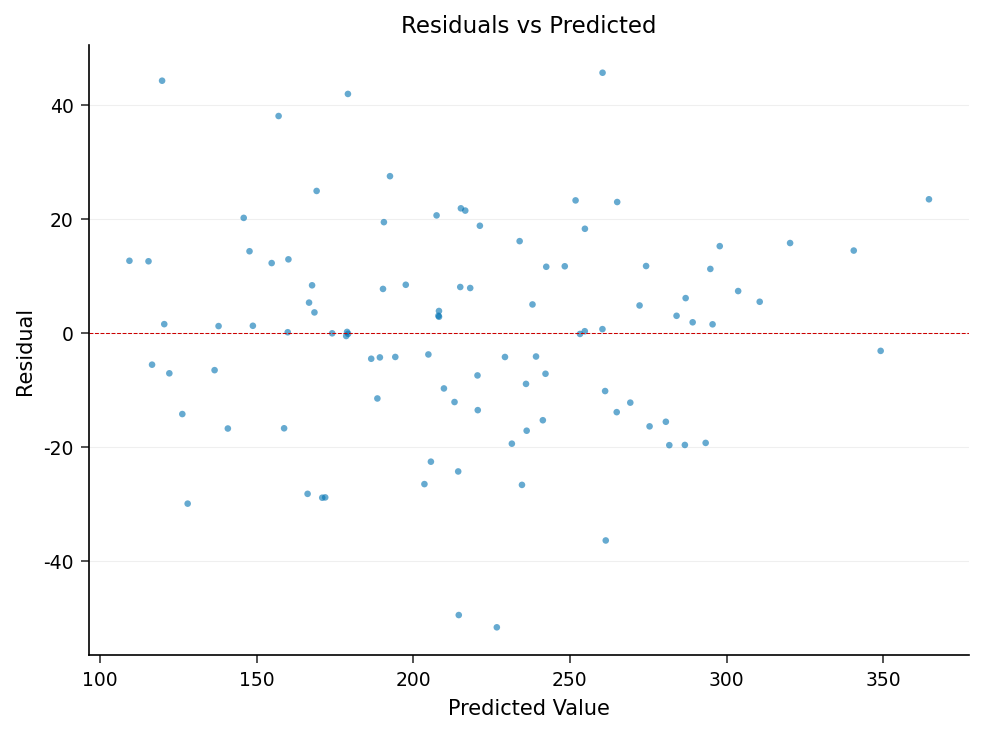

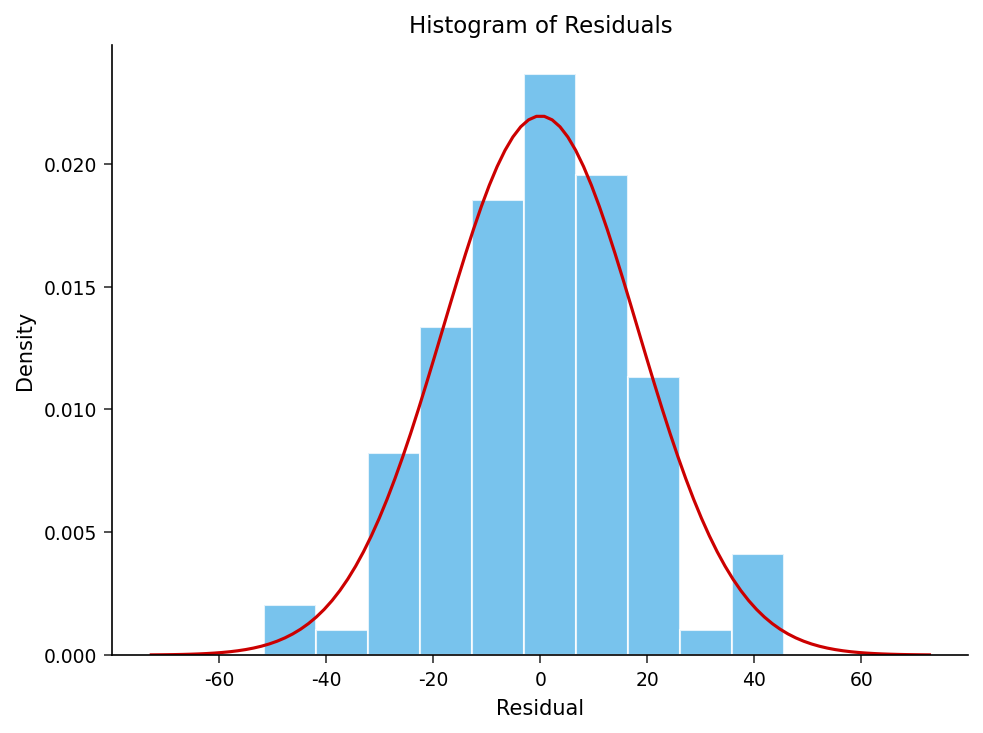

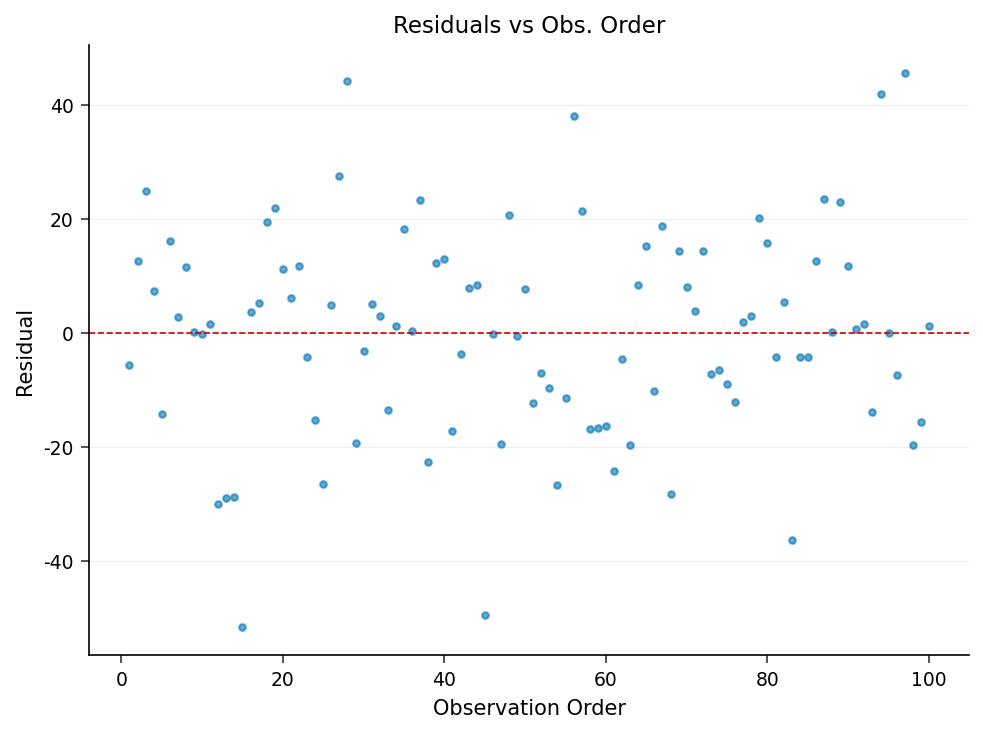

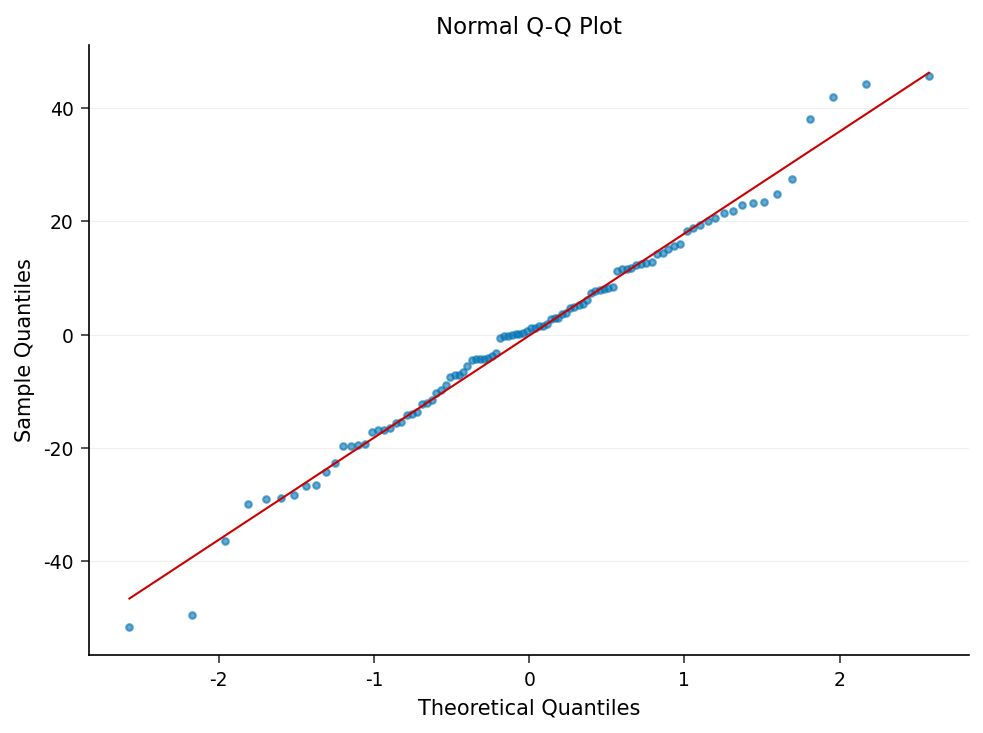

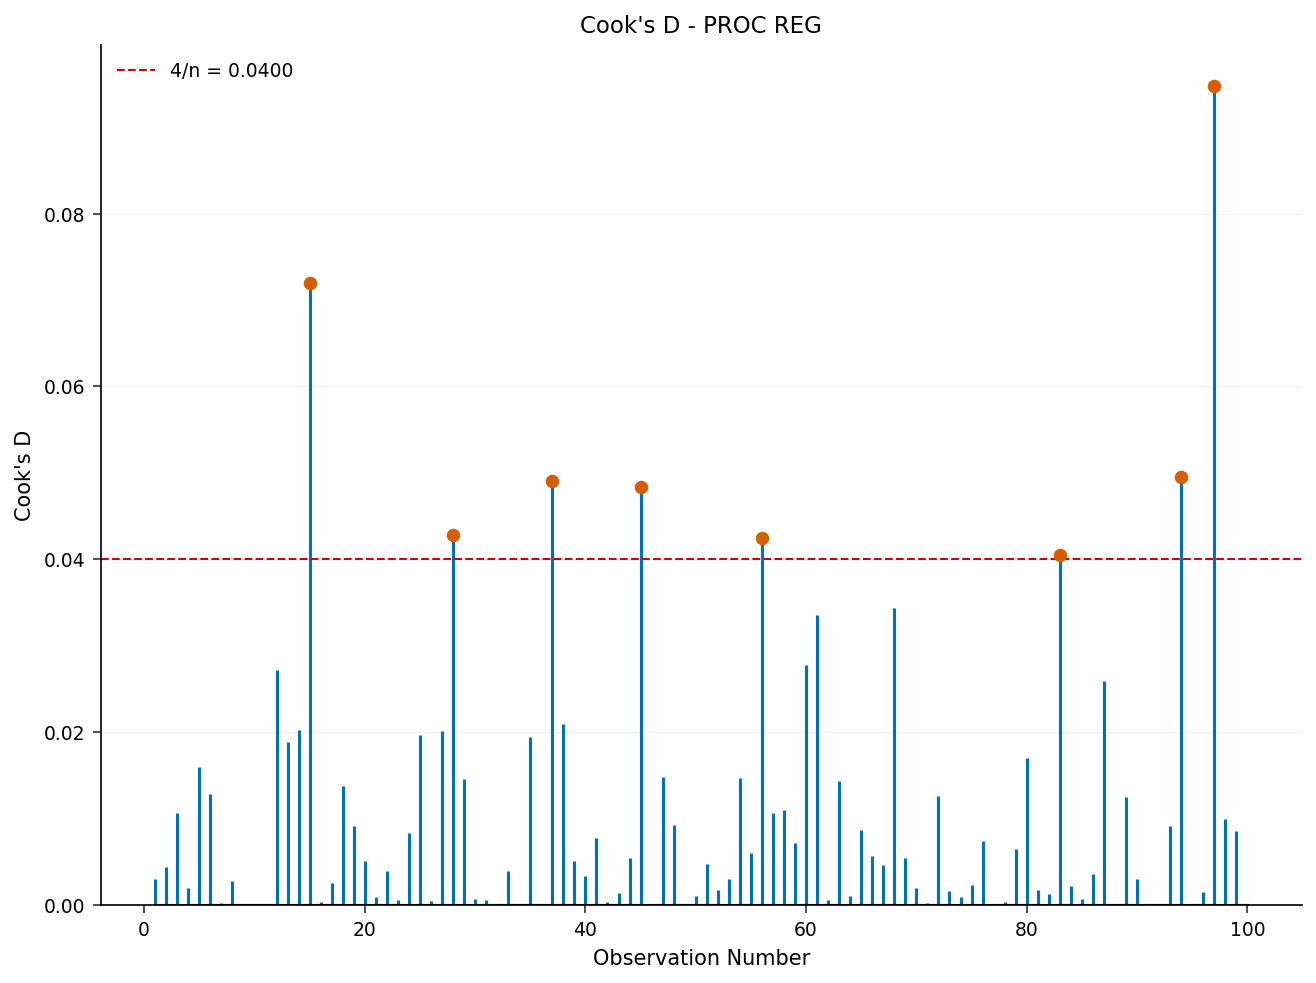

In [4]:
데이터 ws_dummies;
    설정 weekly_sales;
    disp    = (promo = 'Display');
    feat    = (promo = 'Feature');
    cat_bev = (category = 'Beverage');
    cat_gro = (category = 'Grocery');
    cat_hh  = (category = 'HouseHold');
실행;

처리 REG 데이터=ws_dummies;
    모형 units = price discount_pct comp_price disp feat
                  cat_bev cat_gro cat_hh email_spend social_spend holiday
                  / stb clb vif tol;
    라벨 units        = "판매수량"
          price         = "판매가격"
          discount_pct  = "할인율"
          comp_price    = "경쟁사가격"
          disp          = "디스플레이판촉"
          feat          = "특별진열판촉"
          cat_bev       = "카테고리_음료"
          cat_gro       = "카테고리_식료품"
          cat_hh        = "카테고리_생활용품"
          email_spend   = "이메일 지출"
          social_spend  = "소셜 지출"
          holiday       = "공휴일여부";
실행;

## 5단계 — 관측치 채점 및 예측 코드 내보내기

마지막으로 `PROC REG`의 `OUTPUT` 문으로 관측치별 예측값과 잔차를 생성한다 — 채점된 데이터셋은 `role` 지표를 포함한 모든 입력 열을 그대로 유지하므로, 이후 테스트셋 정확도를 평가할 수 있다. 그런 다음 더미코딩된 모델에 `PROC GLMSELECT`와 `CODE FILE=`을 사용하여, 배포팀이 프로시저를 다시 실행하지 않고도 신규 매장-주-SKU 행을 채점할 수 있는 독립형 DATA 스텝 채점 코드를 내보낸다.


        카테고리          판매가격          판촉유형          분할역할          판매수량              예측판매수량          잔차
------------  ------------  ------------  ------------  ------------  ------------------  ----------
HouseHold             9.18  None          TRAIN                  111          116.621687   -5.621687
HouseHold             8.92  None          TRAIN                  122          109.402167   12.597833
Snack                 6.94  None          TRAIN                  194          169.157816   24.842184
Beverage              3.81  None          TEST                   311          303.712702    7.287298
HouseHold             8.35  None          TRAIN                  112          126.281265  -14.281265
HouseHold             4.11  Feature       TRAIN                  250           233.96045    16.03955
HouseHold             3.25  None          TRAIN                  211          208.220298    2.779702
Beverage              6.41  None          VAL                    254          242.453379  


NOTE: PROC REG data=ws_dummies

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: Output dataset sales_scored written.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: PROC PRINT data=sales_scored

NOTE: PROC PRINT completed: 8 observations printed, 7 variables
NOTE: PROC GLMSELECT data=ws_dummies

NOTE: CODE FILE=demand_score.sas written.
NOTE: PROC GLMSELECT statement used.


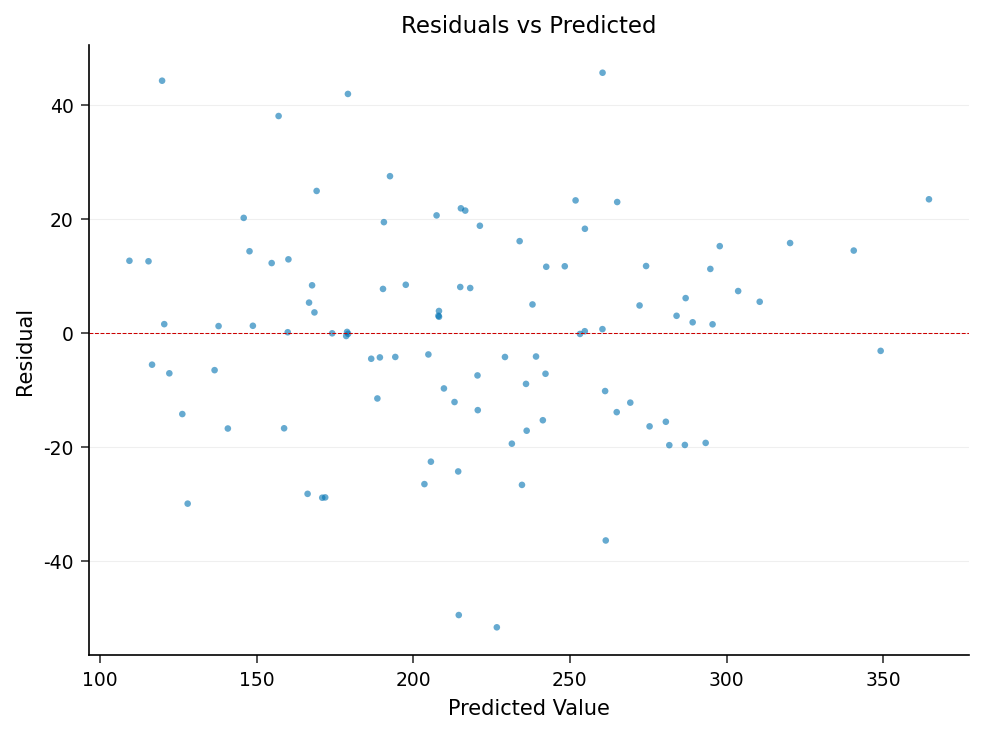

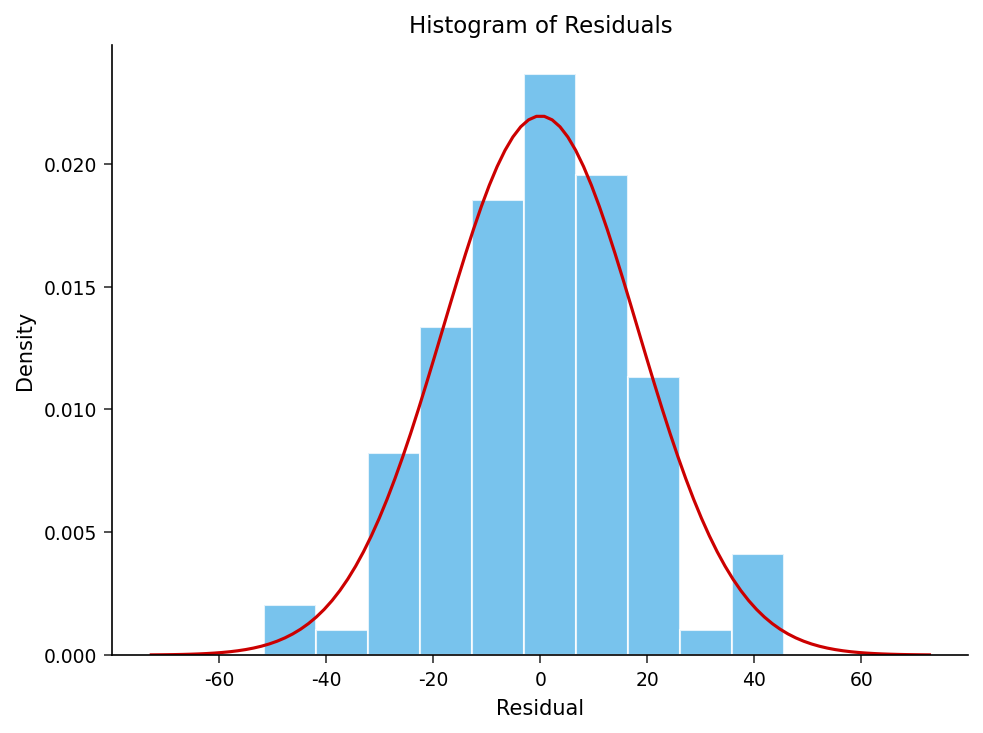

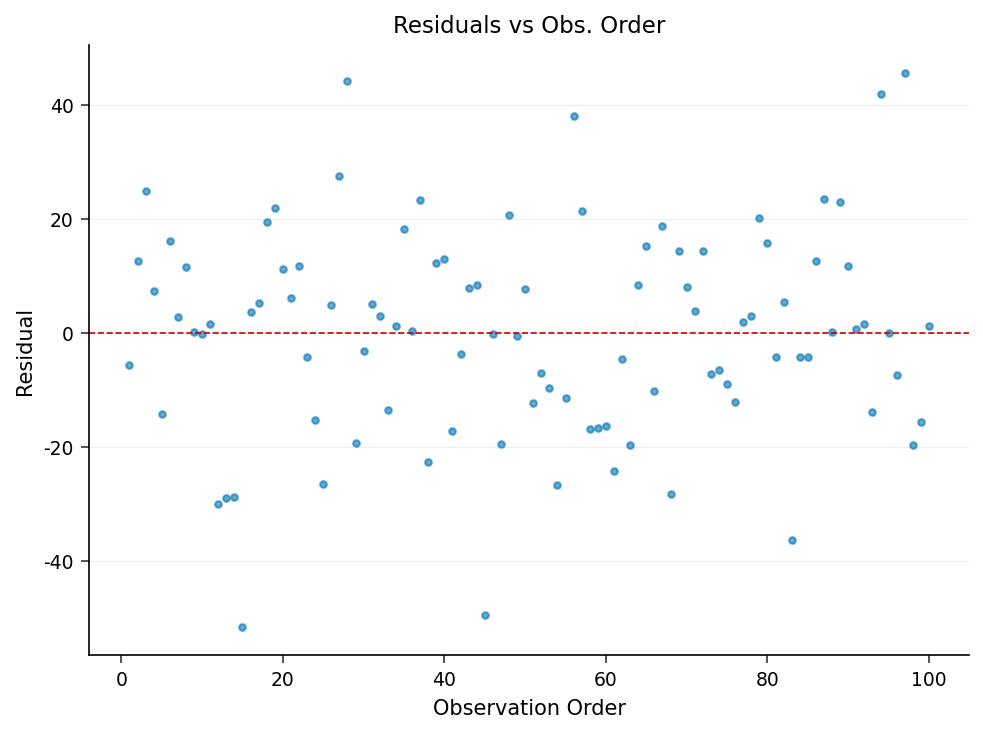

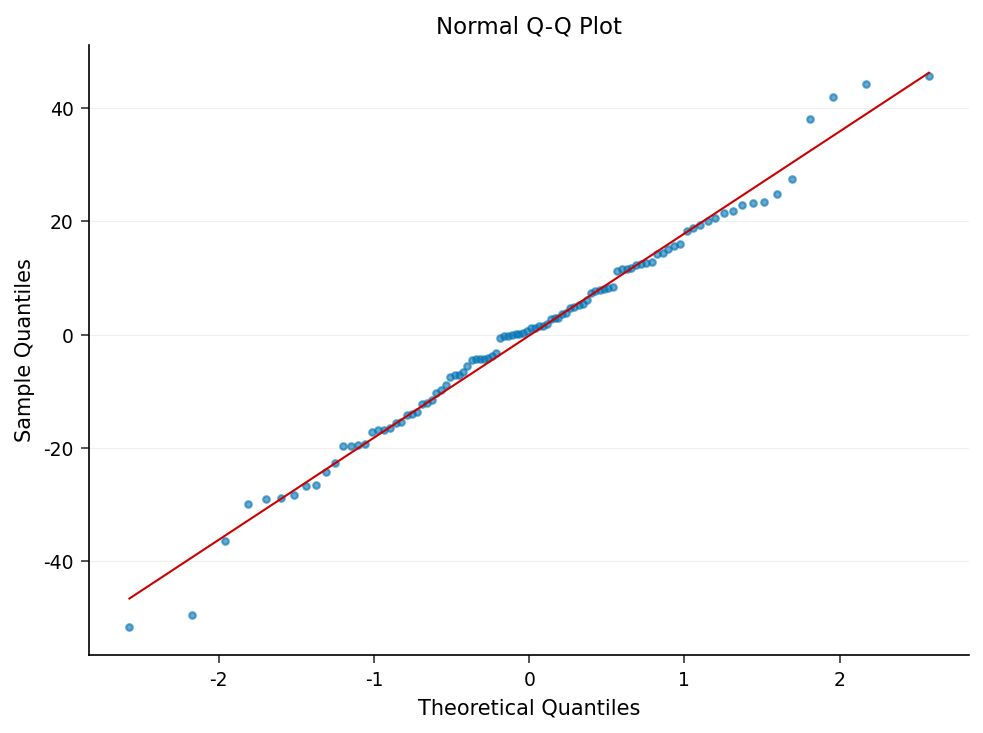

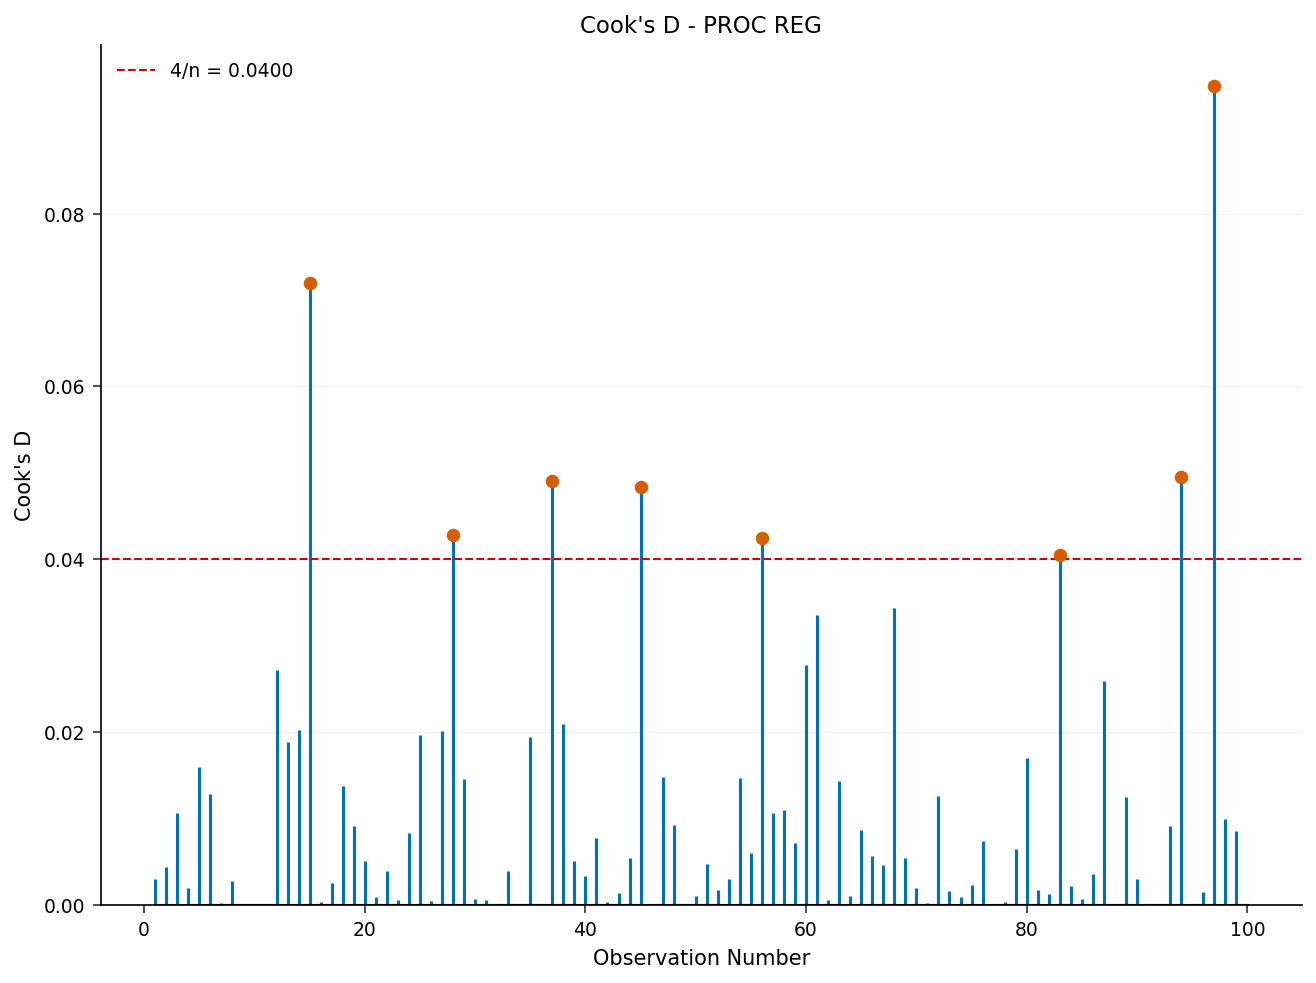

In [5]:
처리 REG 데이터=ws_dummies NOPRINT;
    모형 units = price discount_pct comp_price disp feat
                  cat_bev cat_gro cat_hh email_spend social_spend holiday;
    출력 out=sales_scored p=pred r=resid;
실행;

처리 인쇄 데이터=sales_scored(obs=8) noobs 라벨;
    변수 category price promo role units pred resid;
    라벨 category = "카테고리"
          price     = "판매가격"
          promo     = "판촉유형"
          role      = "분할역할"
          units     = "판매수량"
          pred      = "예측판매수량"
          resid     = "잔차";
실행;

처리 glmselect 데이터=ws_dummies;
    모형 units = price discount_pct comp_price disp feat
                  cat_bev cat_gro cat_hh email_spend social_spend holiday;
    selection METHOD=none;
    code FILE='demand_score.sas';
실행;

## 결과 해석

**검증** 분할에서 선택된 단계적 모델은 단순히 학습 잡음에 적합된 요인이 아니라 실제로 수요를 움직이는 지렛대를 골라낸다.

- **할인 폭**이 가장 큰 표준화 계수(약 +0.71)를 가진다. 일시적 가격인하가 깊을수록 판매수량을 움직이는 가장 강력한 단일 요인이며, 이 카테고리들에서 의미 있는 가격탄력성이 확인된다. 초점을 맞춘 `REG` 재적합에서도 `discount_pct` 한 단위당 +220에 가까운 할인 계수로 이를 그대로 반영한다.
- **판촉 유형**도 중요하다. 재적합에서 특별진열(feature) 판촉은 약 +68, 디스플레이(display) 판촉은 약 +39의 판매수량을 더하며 둘 다 고도로 유의하다. 선택 경로에는 **할인 × 특별진열 상호작용**도 들어가는데, 깊은 할인은 특별진열과 결합될 때 가장 강하게 작동한다.
- **카테고리**는 기저선을 크게 이동시킨다(Beverage는 기준인 Snack보다 훨씬 높고, HouseHold는 그보다 낮다) — 데이터 생성 과정이 의도한 그대로다.
- **마케팅 지출**은 완만하고 체감하는 상승효과를 기여한다(이메일 약 +3.2, 소셜 약 +1.9). 경쟁사 가격이 높을수록 우리 수요는 오히려 올라간다 — 전형적인 교차가격 효과다.
- **공휴일 주간**은 기저선을 높이며, 이는 계절 수요와 일치한다.

VIF 진단은 완전히 깨끗하지는 않은, 유익한 정보를 준다. `price`(VIF ≈ 15)와 `comp_price`(VIF ≈ 14)는 **상당한 다중공선성**을 보이는데, 판매가격, 할인 폭, 경쟁사가격이 모두 같은 기준가에 고정되어 있으므로 예상된 결과다. 나머지 예측변수는 모두 3 이하로 편안한 수준이다. 가격 분석가라면 이를 개별 가격·경쟁사가격 계수가 할인·판촉 효과보다 덜 안정적이라는 주의 신호로 읽을 것이다 — 모델이 의사결정에 반영되기 전에 드러낼 가치가 있는 현실적인 발견이다. 최종 모델이 검증 오차로 선택되었고 채점된 데이터셋이 role 지표를 담고 있으므로, 팀은 채점 코드가 가격·판촉 계획 워크플로에 반영되기 전에 정직한 **테스트셋** 정확도를 보고할 수 있다.